# E-Commerce Revenue Analysis

This project analyzes an online retail dataset to identify sales trends,
top products, and the countries generating the most revenue.

Tools used:
- Python
- Pandas
- Matplotlib
- Jupyter Notebook

## Import Libraries

In [2]:
import pandas as pd
import matplotlib.pyplot as plt

## Load Dataset

In [4]:
file_path = "../data/online_retail.xlsx"
df = pd.read_excel(file_path)

## Inspect Dataset

In [6]:
df.info()
df.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    541909 non-null  object        
 1   StockCode    541909 non-null  object        
 2   Description  540455 non-null  object        
 3   Quantity     541909 non-null  int64         
 4   InvoiceDate  541909 non-null  datetime64[ns]
 5   UnitPrice    541909 non-null  float64       
 6   CustomerID   406829 non-null  float64       
 7   Country      541909 non-null  object        
dtypes: datetime64[ns](1), float64(2), int64(1), object(4)
memory usage: 33.1+ MB


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


## Data Cleaning
Removing missing customer IDs and invalid transactions.

In [8]:
df = df.dropna(subset=["CustomerID"])
df = df[df["Quantity"] > 0]
df = df[df["UnitPrice"] > 0]

df.shape

(397884, 8)

## Feature Engineering
Creating new columns for revenue and monthly analysis.

In [9]:
df["Revenue"] = df["Quantity"] * df["UnitPrice"]

df["InvoiceDate"] = pd.to_datetime(df["InvoiceDate"])

df["Month"] = df["InvoiceDate"].dt.to_period("M")

df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,Revenue,Month
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,15.30,2010-12
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34,2010-12
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom,22.00,2010-12
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34,2010-12
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34,2010-12


## Monthly Revenue Trend

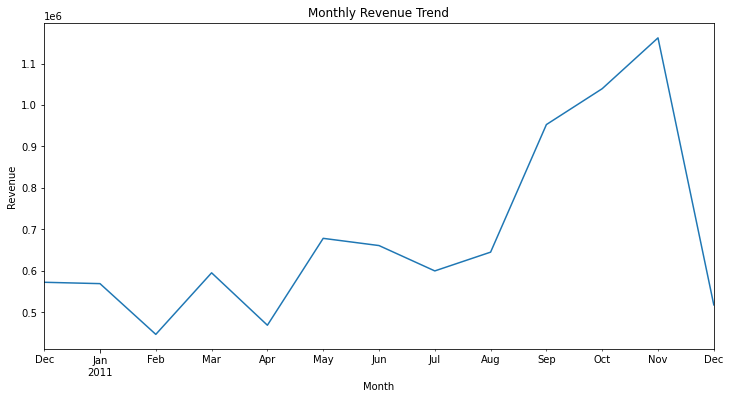

In [10]:
monthly_sales = df.groupby("Month")["Revenue"].sum()

monthly_sales.plot(figsize=(12,6))

plt.title("Monthly Revenue Trend")
plt.xlabel("Month")
plt.ylabel("Revenue")

plt.show()

## Top 10 Products by Revenue

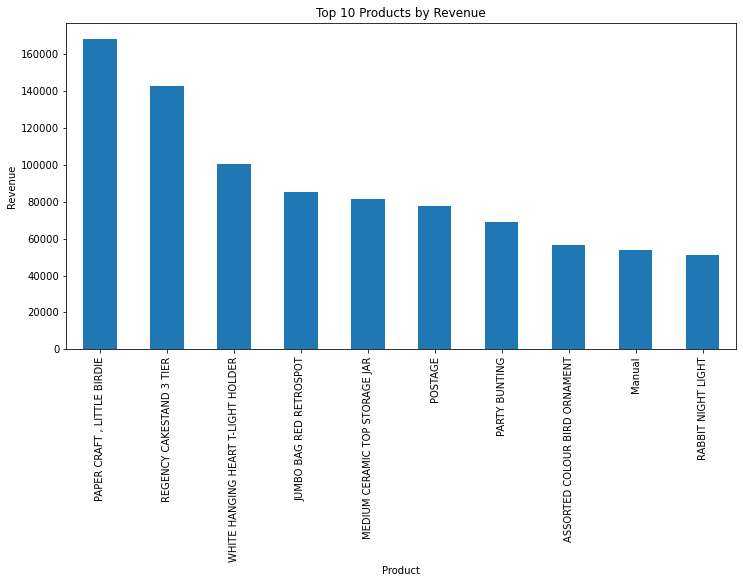

In [11]:
top_products = df.groupby("Description")["Revenue"].sum().sort_values(ascending=False).head(10)

top_products.plot(kind="bar", figsize=(12,6))

plt.title("Top 10 Products by Revenue")
plt.xlabel("Product")
plt.ylabel("Revenue")

plt.show()

## Revenue by Country

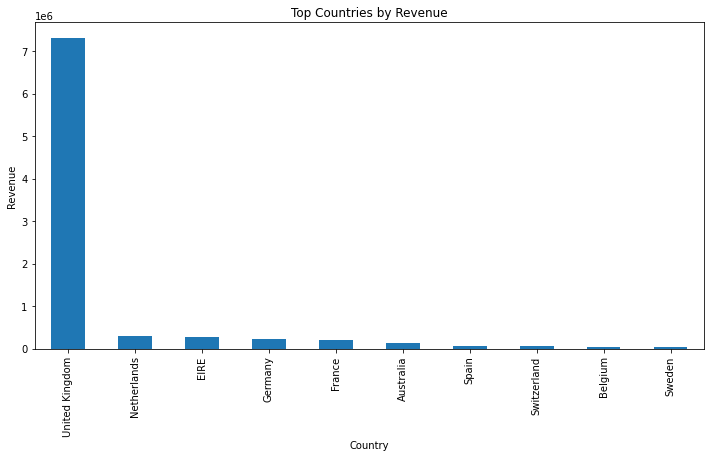

In [12]:
country_sales = df.groupby("Country")["Revenue"].sum().sort_values(ascending=False).head(10)

country_sales.plot(kind="bar", figsize=(12,6))

plt.title("Top Countries by Revenue")
plt.xlabel("Country")
plt.ylabel("Revenue")

plt.show()

## Key Business Insights

1. The United Kingdom generates the majority of total revenue.
2. A small number of products contribute a large portion of sales.
3. Sales increase significantly toward the end of the year.
4. Data cleaning removed invalid transactions and missing customer records.